In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer 


In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Survived,Age,Fare,Family
0,0,22.0,7.2500,1
1,1,38.0,71.2833,1
2,1,26.0,7.9250,0
3,1,35.0,53.1000,1
4,0,35.0,8.0500,0


In [5]:
df.isnull().mean()

Survived    0.000000
Age         0.198653
Fare        0.050505
Family      0.000000
dtype: float64

In [6]:
X = df.drop(columns = ['Survived'])
y = df['Survived']


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)


X_train['Fare_999'] = X_train['Fare'].fillna(999)
X_train['Fare_minus1'] = X_train['Fare'].fillna(-1)

In [10]:
print('Original Age variable variance :',X_train['Age'].var())
print('Age Variance after 99 imputation:',X_train['Age_99'].var())
print('Age Variance after -1 imputation:',X_train['Age_minus1'].var())

print('Original Fare variable variance :',X_train['Fare'].var())
print('Fare Variance after 999 imputation:',X_train['Fare_999'].var())
print('Fare Variance after -1 imputation:',X_train['Fare_minus1'].var())


Original Age variable variance : 204.34951339046142
Age Variance after 99 imputation: 951.7275570187188
Age Variance after -1 imputation: 318.0896202624488
Original Fare variable variance : 2470.643159145907
Fare Variance after 999 imputation: 47218.89723515296
Fare Variance after -1 imputation: 2400.631042577216


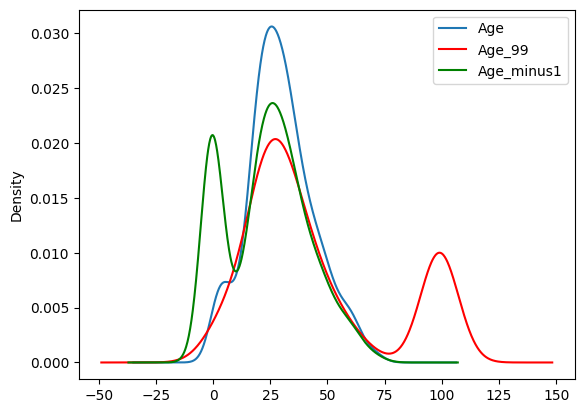

In [14]:
fig = plt.figure()

ax= fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde',ax=ax)

# variable imputed with the 99
X_train['Age_99'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the -1
X_train['Age_minus1'].plot(kind='kde',ax=ax,color='green')

# add legends

lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

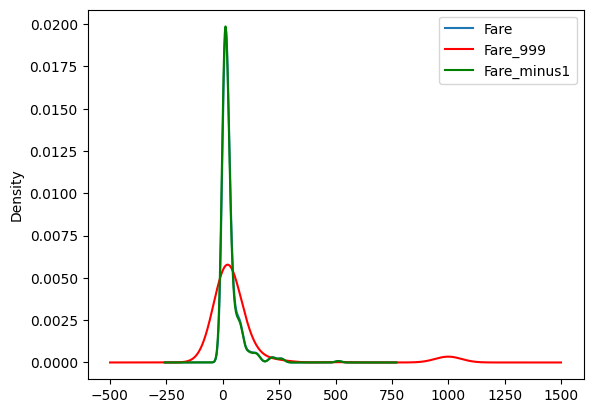

In [15]:
fig = plt.figure()

ax= fig.add_subplot(111)

# original variable distribution
X_train['Fare'].plot(kind='kde',ax=ax)

# variable imputed with the 999
X_train['Fare_999'].plot(kind='kde',ax=ax,color='red')

# variable imputed with the -1

X_train['Fare_minus1'].plot(kind='kde',ax=ax,color='green')

# add legends

lines,labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [16]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,73.136773,-6.498901,204.349513,204.349513,-86.447717,75.576110
Fare,73.136773,2470.643159,17.347633,-98.629416,128.334427,2470.643159,2470.643159
Family,-6.498901,17.347633,2.735252,-7.387287,-4.149246,7.537437,16.782210
Age_99,204.349513,-98.629416,-7.387287,951.727557,-189.535540,-74.926380,-94.291019
Age_minus1,204.349513,128.334427,-4.149246,-189.535540,318.089620,-65.573653,128.402627
Fare_999,-86.447717,2470.643159,7.537437,-74.926380,-65.573653,47218.897235,773.353955
Fare_minus1,75.576110,2470.643159,16.782210,-94.291019,128.402627,773.353955,2400.631043


In [17]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.095289,-0.299113,1.000000,1.000000,-0.028485,0.100581
Fare,0.095289,1.000000,0.209196,-0.064559,0.143969,1.000000,1.000000
Family,-0.299113,0.209196,1.000000,-0.144787,-0.140668,0.020973,0.207104
Age_99,1.000000,-0.064559,-0.144787,1.000000,-0.344476,-0.011177,-0.062381
Age_minus1,1.000000,0.143969,-0.140668,-0.344476,1.000000,-0.016920,0.146939
Fare_999,-0.028485,1.000000,0.020973,-0.011177,-0.016920,1.000000,0.072637
Fare_minus1,0.100581,1.000000,0.207104,-0.062381,0.146939,0.072637,1.000000


Using ScikitLearn


In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [19]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [20]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [21]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [23]:
trf.named_transformers_['imputer1'].statistics_


array([99], dtype=object)

In [24]:
trf.named_transformers_['imputer2'].statistics_

array([999], dtype=object)

In [25]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [26]:
X_train

array([[ 40.    , 999.    ,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))